# Coordinate Relativity — Same Scene, Different Reference Frames

This notebook illustrates the core insight of Coordinatus:
**the same set of points looks completely different depending on your reference space.**

We build a scene with a shared absolute root, then two child spaces:
- **Space 1** (blue): a sheared, rotated, and scaled space
- **Space 2** (green): a rotated and anisotropically-scaled space
- **An F-shaped polygon** defined in Space 1

Then we plot the scene from three viewpoints:
1. Absolute space (the "true" geometry)
2. Space 1 (its own frame — the F looks canonical here)
3. Space 2 (the F appears distorted from here)

> Requires `coordinatus[plotting]` (`matplotlib`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from coordinatus import Space2D, Space, Point, Vector, create_space
from coordinatus.transforms import trks2D
from coordinatus.visualization import draw_space_axes, draw_points

# ── Shared absolute root ─────────────────────────────────────────────────────
absolute = Space2D()

# ── Two child spaces, both rooted in `absolute` ──────────────────────────────
space1 = Space(
    parent=absolute,
    transform=trks2D(
        tx=-1, ty=3,
        angle_rad=-np.pi / 4,
        kx=1, ky=0,
        sx=0.8, sy=0.8,
    ),
)

space2 = create_space(
    parent=absolute,
    tx=2, ty=1,
    angle_rad=np.pi / 6,
    sx=1.2, sy=0.6,
)

# ── F-shaped polygon defined in Space 1 ──────────────────────────────────────
f_coords = [
    [2.0, 2.0],
    [1.0, 2.0],
    [1.0, 1.0],
    [1.0, 3.0],
    [2.5, 3.0],
]
points = [Point(np.array(c), space=space1) for c in f_coords]

print("Scene ready — Space 1 and Space 2 share the absolute root.")


Scene ready — Space 1 and Space 2 share the absolute root.


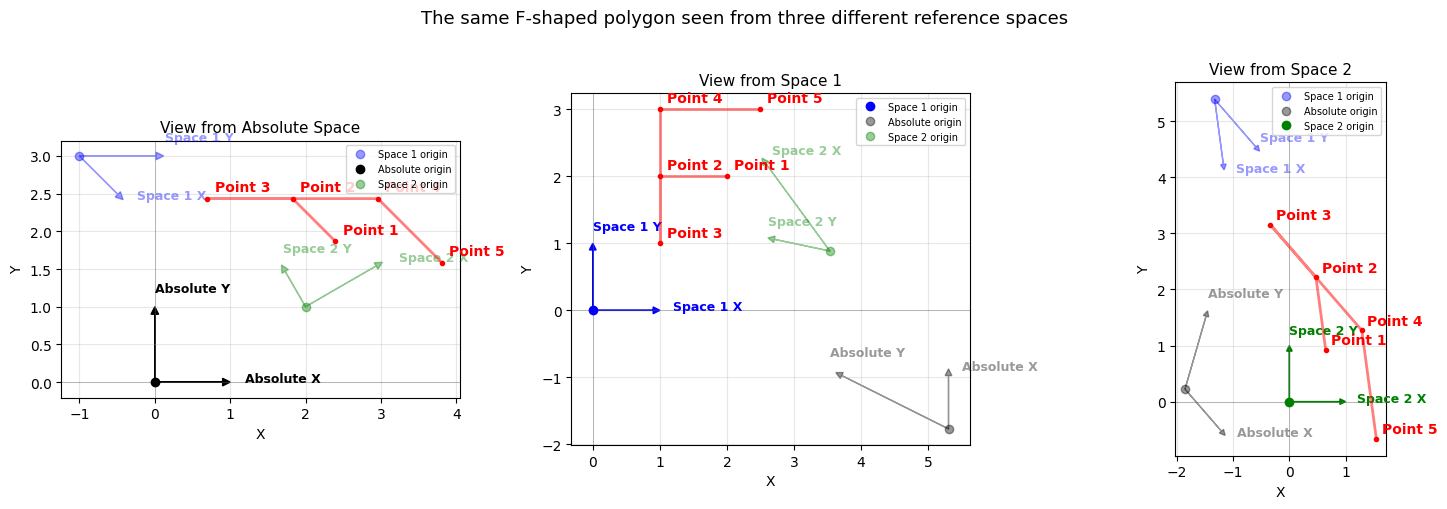

In [2]:
def setup_ax(ax, title):
    ax.set_aspect("equal")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="k", linewidth=0.5, alpha=0.3)
    ax.axvline(0, color="k", linewidth=0.5, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

views = [
    (None,   "View from Absolute Space"),
    (space1, "View from Space 1"),
    (space2, "View from Space 2"),
]

for ax, (ref_space, title) in zip(axes, views):
    draw_space_axes(ax, space1,    ref_space, color="blue",  label="Space 1",
                    alpha=1.0 if ref_space is space1 else 0.4)
    draw_space_axes(ax, absolute,  ref_space, color="black", label="Absolute",
                    alpha=1.0 if ref_space is None   else 0.4)
    draw_space_axes(ax, space2,    ref_space, color="green", label="Space 2",
                    alpha=1.0 if ref_space is space2 else 0.4)
    draw_points(ax, points, ref_space, color="red")
    setup_ax(ax, title)

plt.suptitle(
    "The same F-shaped polygon seen from three different reference spaces",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


## What you see

| View | Observation |
|---|---|
| **Absolute** | The true geometry: Space 1 (blue) is sheared and its F inherits that shear; Space 2 (green) is rotated and anisotropically scaled. |
| **Space 1** | The F is undistorted — Space 1's axes are the natural orthogonal basis here. Space 2 (green) appears at a different location and orientation. |
| **Space 2** | Space 2's axes are now the reference — the F appears with a completely different orientation and distortion even though nothing physically changed. |

**Key insight:** coordinates are not absolute — they depend on the observer. This is why Coordinatus always associates a coordinate with its space: the same numerical values mean completely different things in different frames.
